# 05_02 Global LightGBM by frozen ADI/CV² regime

WHY IT IS HERE: this notebook should answer the question whether local model makes sense when grouping products per demand. The terciles of ADI and CV2 are used because the default cutoffs come from industrial data. For this data almost every series is above 1.32, which leaves erratic and smooth classes empty. So, the classes get splitted only by CV2.

This notebook explains the selected global LightGBM model's test performance by demand regime. The regime is frozen before evaluation: the cutoff is the first evaluation refit's validation start, so the history contains only rows available to the fitted training block. Series with fewer than five positive-demand days are labelled `insufficient`; all others are split into ADI and CV² terciles.

The marginal comparison shows that pooled WAPE spans 37.38 percentage points across ADI terciles but only 4.93 points across CV² terciles. Following that result, the report uses the cleaner three-row ADI table as its primary result, retains the three-row CV² table as the diagnostic evidence, and omits the 3×3 accuracy table. The final table still shows the requested sourcing-group composition within every ADI/CV² cell.

CV² is a documented null. SBC treats ADI and CV² as co-equal axes, and on daily retail data CV2 does nothing.

ANSWER on local models: the case is weak. The ratio spread across ADI terciles is 0.084 — and CV²'s is 0.081 despite CV² carrying no accuracy signal at all. So 0.08 is roughly the noise floor, not evidence of regime-specific bias. What is real is that the ratio gradient is monotone: 0.984 → 1.013 → 1.068. The model over-forecasts intermittent series by ~7%. But that's 7% on 8.9% of volume — a per-tercile bias correction captures nearly all of it for the cost of three constants, versus retraining three models.

In [6]:
from pathlib import Path
import json
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import load_benchmark_design
from src.models.lightgbm import LIGHTGBM_MODEL_LABELS, TWO_STAGE_MODEL_NAME
from src.models.results import read_result, result_path

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 40)

SERIES_COLS = ['ARTIKEL_ID', 'MARKT_ID']
ADI_LABELS = ['A1', 'A2', 'A3']
CV2_LABELS = ['C1', 'C2', 'C3']
CELL_ORDER = [f'{adi}-{cv2}' for adi in ADI_LABELS for cv2 in CV2_LABELS] + ['insufficient']
ANALYSIS_MODEL = TWO_STAGE_MODEL_NAME

## Frozen classification cutoff

The first refit trains through its final seven-day fit origin and begins validation at `validation_start`. Consequently, dates strictly before `validation_start` are the first evaluation origin's training history. The feature partition at that date contains cumulative ADI, CV², active-day counts, and positive-demand-day counts calculated strictly before the origin.

In [7]:
design = load_benchmark_design()
training_summary = read_result(
    ANALYSIS_MODEL, design, artifact='training_summaries'
)
first_refit = (
    training_summary.sort_values('evaluation_origin').iloc[0]
)
first_evaluation_origin = pd.Timestamp(first_refit.evaluation_origin).normalize()
training_cutoff = pd.Timestamp(first_refit.validation_start).normalize()
expected_cutoff = (
    pd.Timestamp(first_refit.training_end).normalize()
    + pd.Timedelta(days=design.forecast_horizon_days)
)
if training_cutoff != expected_cutoff:
    raise ValueError(
        'The inferred cutoff does not immediately follow the final fit horizon: '
        f'{training_cutoff.date()} != {expected_cutoff.date()}'
    )

forecast_path = result_path(ANALYSIS_MODEL, design)
forecast_columns = [
    *SERIES_COLS, 'sourcing_group', 'category_id', 'origin', 'actual', 'is_active',
    'model', 'forecast',
]
forecasts = pd.read_csv(
    forecast_path, usecols=forecast_columns, parse_dates=['origin']
)
if forecasts.model.nunique() != 1 or forecasts.model.iloc[0] != ANALYSIS_MODEL:
    raise ValueError('Forecast artifact does not contain the requested model')
forecasts = forecasts.loc[forecasts.is_active].copy()
forecasts['abs_error'] = (forecasts.forecast - forecasts.actual).abs()

series_attributes = forecasts[[
    *SERIES_COLS, 'sourcing_group', 'category_id'
]].drop_duplicates()
if series_attributes.duplicated(SERIES_COLS).any():
    raise ValueError(
        'Sourcing group or category changes within at least one forecast series'
    )

display(pd.DataFrame([{
    'model': LIGHTGBM_MODEL_LABELS[ANALYSIS_MODEL],
    'first_evaluation_origin': first_evaluation_origin,
    'training_cutoff': training_cutoff,
    'last_training_date_included': training_cutoff - pd.Timedelta(days=1),
    'forecast_rows': len(forecasts),
    'forecast_series': len(series_attributes),
}]).style.format({
    'first_evaluation_origin': '{:%Y-%m-%d}',
    'training_cutoff': '{:%Y-%m-%d}',
    'last_training_date_included': '{:%Y-%m-%d}',
    'forecast_rows': '{:,.0f}',
    'forecast_series': '{:,.0f}',
}))

,model,first_evaluation_origin,training_cutoff,last_training_date_included,forecast_rows,forecast_series
0,Two-stage LightGBM (occurrence × quantity),2026-03-02,2026-02-02,2026-02-01,"2,511,229","21,937"


In [8]:
FEATURE_STORE_ROOT = ROOT / 'data' / 'processed' / 'model_features'

def matching_feature_partition(cutoff):
    matches = []
    for manifest_path in FEATURE_STORE_ROOT.rglob('manifest.json'):
        try:
            manifest = json.loads(manifest_path.read_text())
            cached_design = manifest['signature']['forecast_design']
        except (OSError, KeyError, json.JSONDecodeError, TypeError):
            continue
        same_design = (
            cached_design.get('first_origin') == design.first_origin.date().isoformat()
            and int(cached_design.get('forecast_horizon_days', -1)) == design.forecast_horizon_days
            and int(cached_design.get('origin_spacing_days', -1)) == design.origin_spacing_days
            and int(cached_design.get('min_active_days', -1)) == design.min_active_days
            and Path(cached_design.get('data_dir', '')).resolve() == design.data_dir.resolve()
        )
        partition = (
            manifest_path.parent
            / f'origin={cutoff.date().isoformat()}'
            / 'features.parquet'
        )
        if same_design and partition.exists():
            matches.append((manifest_path.stat().st_mtime, partition))
    if not matches:
        raise FileNotFoundError(
            f'No matching cached feature partition exists for {cutoff.date()}'
        )
    return max(matches, key=lambda item: item[0])[1]

feature_partition = matching_feature_partition(training_cutoff)
snapshot_columns = [
    *SERIES_COLS, 'active_days_before_origin',
    'demand_days_before_origin', 'ADI', 'CV2',
]
cached_snapshot = pd.read_parquet(
    feature_partition, columns=snapshot_columns
).drop_duplicates()
if cached_snapshot.duplicated(SERIES_COLS).any():
    raise ValueError('Cached regime features vary within a series at the cutoff')
cached_snapshot = cached_snapshot.rename(columns={
    'active_days_before_origin': 'n_operational_days',
    'demand_days_before_origin': 'n_pos',
})

series_regimes = series_attributes.merge(
    cached_snapshot[[*SERIES_COLS, 'n_operational_days', 'n_pos', 'ADI', 'CV2']],
    on=SERIES_COLS, how='left', validate='one_to_one', indicator=True,
)
missing_keys = series_regimes.loc[
    series_regimes['_merge'].eq('left_only'), SERIES_COLS
].copy()

# Later-maturing evaluation series are absent from the cutoff partition.
# Calculate only those series from active daily rows strictly before cutoff,
# using VAR_POP to match the cached feature-store CV² convention.
if not missing_keys.empty:
    con = duckdb.connect()
    con.execute('PRAGMA threads=4')
    con.register('missing_series', missing_keys)
    transaction_glob = str(design.data_dir / '*.parquet')
    fallback = con.execute(
        '''
        WITH daily AS (
            SELECT
                d.ARTIKEL_ID, d.MARKT_ID, CAST(d.DATE AS DATE) AS period,
                SUM(CAST(COALESCE(d.ABVERKAUFTE_MENGE_KG, 0) AS DOUBLE)) AS demand
            FROM read_parquet(?) AS d
            INNER JOIN missing_series AS s USING (ARTIKEL_ID, MARKT_ID)
            WHERE d.is_active
              AND (d.is_fcm OR d.is_pseudo)
              AND d.WGR_ID IN (890, 900)
              AND CAST(d.DATE AS DATE) < ?
            GROUP BY d.ARTIKEL_ID, d.MARKT_ID, period
        ), history AS (
            SELECT
                ARTIKEL_ID, MARKT_ID, COUNT(*) AS n_operational_days,
                COUNT_IF(demand > 0) AS n_pos,
                AVG(demand) FILTER (WHERE demand > 0) AS positive_mean,
                VAR_POP(demand) FILTER (WHERE demand > 0) AS positive_variance
            FROM daily
            GROUP BY ARTIKEL_ID, MARKT_ID
        )
        SELECT
            ARTIKEL_ID, MARKT_ID, n_operational_days, n_pos,
            n_operational_days::DOUBLE / NULLIF(n_pos, 0) AS ADI,
            positive_variance / NULLIF(positive_mean * positive_mean, 0) AS CV2
        FROM history
        ''',
        [transaction_glob, training_cutoff.date()],
    ).fetchdf()
    con.close()
    fallback = missing_keys.merge(
        fallback, on=SERIES_COLS, how='left', validate='one_to_one'
    )
    fallback[['n_operational_days', 'n_pos']] = fallback[[
        'n_operational_days', 'n_pos'
    ]].fillna(0)
    missing_index = series_regimes['_merge'].eq('left_only')
    series_regimes.loc[missing_index, [
        'n_operational_days', 'n_pos', 'ADI', 'CV2'
    ]] = fallback.set_index(SERIES_COLS).reindex(
        pd.MultiIndex.from_frame(series_regimes.loc[missing_index, SERIES_COLS])
    )[['n_operational_days', 'n_pos', 'ADI', 'CV2']].to_numpy()

series_regimes['n_operational_days'] = series_regimes.n_operational_days.astype('int64')
series_regimes['n_pos'] = series_regimes.n_pos.astype('int64')
eligible = series_regimes.n_pos.ge(5)
if series_regimes.loc[eligible, ['ADI', 'CV2']].isna().any().any():
    raise ValueError('ADI/CV² is missing for a series with at least five positives')

adi_bins, adi_edges = pd.qcut(
    series_regimes.loc[eligible, 'ADI'], 3, labels=ADI_LABELS, retbins=True
)
cv2_bins, cv2_edges = pd.qcut(
    series_regimes.loc[eligible, 'CV2'], 3, labels=CV2_LABELS, retbins=True
)
series_regimes['adi_bin'] = pd.Series(pd.NA, index=series_regimes.index, dtype='string')
series_regimes['cv2_bin'] = pd.Series(pd.NA, index=series_regimes.index, dtype='string')
series_regimes.loc[eligible, 'adi_bin'] = adi_bins.astype('string').to_numpy()
series_regimes.loc[eligible, 'cv2_bin'] = cv2_bins.astype('string').to_numpy()
series_regimes['cell'] = 'insufficient'
series_regimes.loc[eligible, 'cell'] = (
    series_regimes.loc[eligible, 'adi_bin']
    + '-'
    + series_regimes.loc[eligible, 'cv2_bin']
)
series_regimes['cell'] = pd.Categorical(
    series_regimes.cell, categories=CELL_ORDER, ordered=True
)
series_regimes = series_regimes.drop(columns='_merge')

bin_edges = pd.DataFrame({
    'dimension': ['ADI', 'CV²'],
    'tercile_edges': [
        ' | '.join(f'{value:.4g}' for value in adi_edges),
        ' | '.join(f'{value:.4g}' for value in cv2_edges),
    ],
})
classification_audit = pd.DataFrame([{
    'feature_partition': feature_partition.relative_to(ROOT),
    'series_from_cache': len(series_regimes) - len(missing_keys),
    'later_maturing_series_recomputed': len(missing_keys),
    'insufficient_series': series_regimes.cell.eq('insufficient').sum(),
    'classified_series': eligible.sum(),
}])
display(classification_audit.style.format({
    'series_from_cache': '{:,.0f}',
    'later_maturing_series_recomputed': '{:,.0f}',
    'insufficient_series': '{:,.0f}',
    'classified_series': '{:,.0f}',
}))
display(bin_edges)

,feature_partition,series_from_cache,later_maturing_series_recomputed,insufficient_series,classified_series
0,data/processed/model_features/lightgbm_daily/v1/e83253e74c052146e7fe/origin=2026-02-02/features.parquet,"20,854","1,083",782,"21,155"


,dimension,tercile_edges
0,ADI,1 | 2.201 | 4.602 | 153.4
1,CV²,0.0007051 | 0.6043 | 0.964 | 7.188


## Accuracy by demand regime

`vol_share` is the cell's share of all evaluated actual kilograms. `ratio` is forecast kilograms divided by actual kilograms. `pp_vs_zero = 100 × (1 − pooled WAPE)`, so a positive value beats forecasting zero. The one-dimensional tables intentionally exclude `insufficient` from their rows while retaining the full evaluation population as the share denominator.

Primary result: ADI terciles


,adi_bin,n_series,series_share,vol_share,pooled_wape,median_series_wape,ratio,pp_vs_zero
0,A1,"7,065",32.2%,73.1%,49.96%,69.08%,0.977,+50.04
1,A2,"7,038",32.1%,17.6%,77.45%,95.57%,1.011,+22.55
2,A3,"7,052",32.1%,8.9%,87.45%,104.82%,1.065,+12.55


CV² terciles


,cv2_bin,n_series,series_share,vol_share,pooled_wape,median_series_wape,ratio,pp_vs_zero
0,C1,"7,052",32.1%,20.4%,58.17%,100.46%,1.047,+41.83
1,C2,"7,051",32.1%,24.5%,61.68%,89.80%,1.014,+38.32
2,C3,"7,052",32.1%,54.7%,56.61%,77.32%,0.960,+43.39


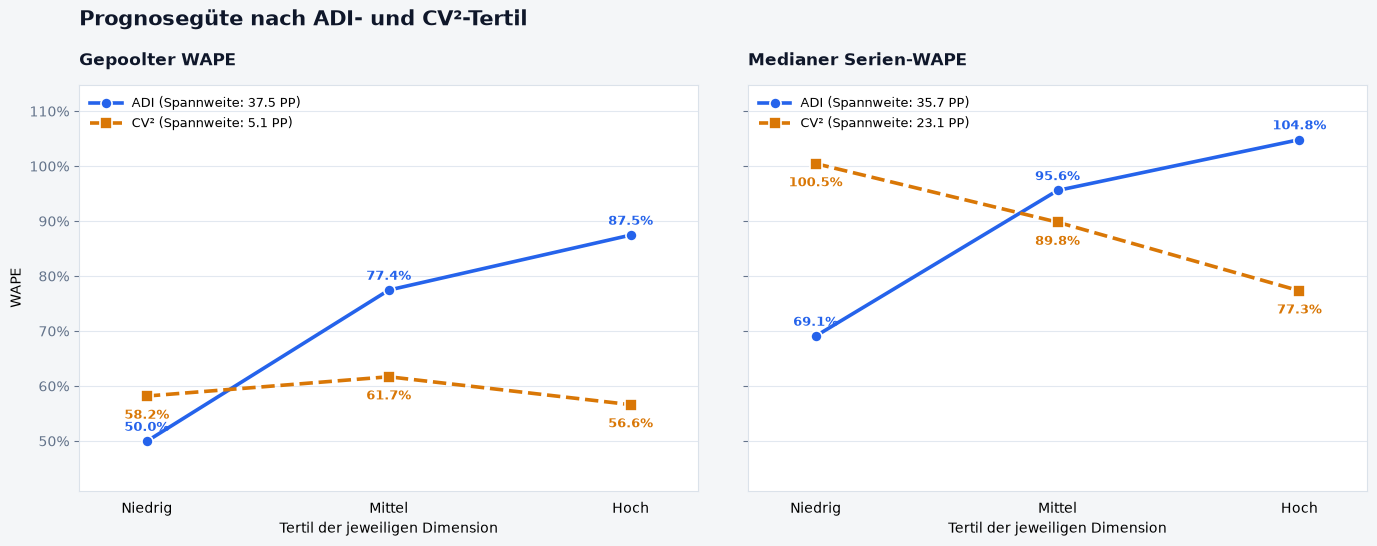

Marginal contrast (larger range = stronger separation)


,dimension,pooled_wape_range_pp,ratio_range
0,ADI,37.49,0.088
1,CV²,5.07,0.087


In [11]:
forecast_classes = forecasts.merge(
    series_regimes[[*SERIES_COLS, 'adi_bin', 'cv2_bin', 'cell']],
    on=SERIES_COLS, how='left', validate='many_to_one',
)
if forecast_classes.cell.isna().any():
    raise ValueError('At least one active forecast row has no frozen demand class')

def regime_accuracy(rows, segment, *, share_base):
    series = (
        rows.groupby([segment, *SERIES_COLS], observed=True)
        .agg(abs_error=('abs_error', 'sum'), actual=('actual', 'sum'))
        .reset_index()
    )
    series['series_wape'] = series.abs_error / series.actual.replace(0, np.nan)
    series_summary = (
        series.groupby(segment, observed=True)
        .agg(
            n_series=('ARTIKEL_ID', 'size'),
            median_series_wape=('series_wape', 'median'),
        )
    )
    grouped = (
        rows.groupby(segment, observed=True)
        .agg(
            actual_kg=('actual', 'sum'),
            forecast_kg=('forecast', 'sum'),
            absolute_error_kg=('abs_error', 'sum'),
        )
        .join(series_summary)
        .reset_index()
    )
    grouped['series_share'] = (
        grouped.n_series
        / len(share_base[SERIES_COLS].drop_duplicates())
    )
    grouped['vol_share'] = grouped.actual_kg / share_base.actual.sum()
    grouped['pooled_wape'] = grouped.absolute_error_kg / grouped.actual_kg
    grouped['ratio'] = grouped.forecast_kg / grouped.actual_kg
    grouped['pp_vs_zero'] = 100 * (1 - grouped.pooled_wape)
    return grouped[[
        segment, 'n_series', 'series_share', 'vol_share', 'pooled_wape',
        'median_series_wape', 'ratio', 'pp_vs_zero',
    ]]

TABLE_FORMAT = {
    'n_series': '{:,.0f}',
    'series_share': '{:.1%}',
    'vol_share': '{:.1%}',
    'pooled_wape': '{:.2%}',
    'median_series_wape': '{:.2%}',
    'ratio': '{:.3f}',
    'pp_vs_zero': '{:+.2f}',
}

classified_forecasts = forecast_classes.loc[
    forecast_classes.cell.ne('insufficient')
].copy()
adi_table = regime_accuracy(
    classified_forecasts, 'adi_bin', share_base=forecast_classes
).set_index('adi_bin').reindex(ADI_LABELS).reset_index()
cv2_table = regime_accuracy(
    classified_forecasts, 'cv2_bin', share_base=forecast_classes
).set_index('cv2_bin').reindex(CV2_LABELS).reset_index()

print('Primary result: ADI terciles')
display(adi_table.style.format(TABLE_FORMAT))
print('CV² terciles')
display(cv2_table.style.format(TABLE_FORMAT))

tercile_positions = np.arange(1, 4)
wape_panels = {
    'Gepoolter WAPE': {
        'ADI': adi_table.pooled_wape.to_numpy(),
        'CV²': cv2_table.pooled_wape.to_numpy(),
    },
    'Medianer Serien-WAPE': {
        'ADI': adi_table.median_series_wape.to_numpy(),
        'CV²': cv2_table.median_series_wape.to_numpy(),
    },
}
series_style = {
    'ADI': {'color': '#2563eb', 'marker': 'o', 'linestyle': '-'},
    'CV²': {'color': '#d97706', 'marker': 's', 'linestyle': '--'},
}
all_wape_values = np.concatenate([
    values for panel in wape_panels.values() for values in panel.values()
])
shared_wape_limits = (
    max(0, all_wape_values.min() - .09),
    min(1.20, all_wape_values.max() + .10),
)
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5.8), sharey=True, facecolor='#f4f6f8',
)
for ax, (panel_title, wape_series) in zip(axes, wape_panels.items()):
    ax.set_facecolor('white')
    for dimension, values in wape_series.items():
        wape_range_pp = 100 * (values.max() - values.min())
        ax.plot(
            tercile_positions, values, linewidth=2.6, markersize=8,
            markeredgecolor='white', markeredgewidth=1.2,
            label=f'{dimension} (Spannweite: {wape_range_pp:.1f} PP)',
            **series_style[dimension],
        )
        label_offset = .025 if dimension == 'ADI' else -.035
        for x_position, value in zip(tercile_positions, values):
            ax.text(
                x_position, value + label_offset, f'{value:.1%}',
                ha='center', va='center', fontsize=9.5,
                weight='bold', color=series_style[dimension]['color'],
            )
    ax.set_xticks(tercile_positions, ['Niedrig', 'Mittel', 'Hoch'])
    ax.set_xlim(.72, 3.28)
    ax.set_ylim(*shared_wape_limits)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel('Tertil der jeweiligen Dimension')
    ax.set_title(
        panel_title, loc='left', fontsize=12, weight='bold',
        color='#0f172a', pad=14,
    )
    ax.legend(
        loc='upper left', frameon=False, fontsize=9, handlelength=2.5,
    )
    ax.grid(axis='y', color='#e2e8f0', linewidth=.8)
    ax.grid(axis='x', visible=False)
    ax.tick_params(axis='x', length=0, pad=8)
    ax.tick_params(axis='y', colors='#64748b')
    for spine in ax.spines.values():
        spine.set_color('#dbe2ea')
        spine.set_linewidth(.8)
axes[0].set_ylabel('WAPE')
fig.suptitle(
    'Prognosegüte nach ADI- und CV²-Tertil',
    x=.065, y=.97, ha='left', fontsize=15, weight='bold', color='#0f172a',
)
fig.subplots_adjust(left=.065, right=.985, bottom=.14, top=.84, wspace=.08)
plt.show()

dimension_contrast = pd.DataFrame([
    {
        'dimension': 'ADI',
        'pooled_wape_range_pp': 100 * (adi_table.pooled_wape.max() - adi_table.pooled_wape.min()),
        'ratio_range': adi_table.ratio.max() - adi_table.ratio.min(),
    },
    {
        'dimension': 'CV²',
        'pooled_wape_range_pp': 100 * (cv2_table.pooled_wape.max() - cv2_table.pooled_wape.min()),
        'ratio_range': cv2_table.ratio.max() - cv2_table.ratio.min(),
    },
])
print('Marginal contrast (larger range = stronger separation)')
display(dimension_contrast.style.format({
    'pooled_wape_range_pp': '{:.2f}', 'ratio_range': '{:.3f}'
}))

## Sourcing-group composition within each cell

Counts are distinct article-store series, split into `FCM 890`, `FCM 900`, `Pseudo 890`, and `Pseudo 900`. Both percentage columns use the ADI/CV² cell as their denominator: `series_share_within_cell` describes representation, while `vol_share_within_cell` describes actual evaluation volume.

In [10]:
SOURCE_ORDER = ['FCM', 'Pseudo']
CATEGORY_ORDER = [890, 900]
valid_source_category = (
    forecast_classes.sourcing_group.isin(SOURCE_ORDER)
    & forecast_classes.category_id.isin(CATEGORY_ORDER)
)
if not valid_source_category.all():
    raise ValueError('Unexpected sourcing-group/category combination')

cell_source_series = (
    forecast_classes[[
        *SERIES_COLS, 'cell', 'sourcing_group', 'category_id'
    ]]
    .drop_duplicates()
)
if cell_source_series.duplicated([*SERIES_COLS, 'cell']).any():
    raise ValueError(
        'A series has multiple sourcing/category groups within a frozen cell'
    )

source_index = pd.MultiIndex.from_product(
    [CELL_ORDER, SOURCE_ORDER, CATEGORY_ORDER],
    names=['cell', 'sourcing_group', 'category_id'],
)
source_counts = (
    cell_source_series.groupby(
        ['cell', 'sourcing_group', 'category_id'], observed=True
    )
    .size().rename('n_series')
    .reindex(source_index, fill_value=0).reset_index()
)
source_volume = (
    forecast_classes.groupby(
        ['cell', 'sourcing_group', 'category_id'], observed=True
    )
    .actual.sum().rename('actual_kg')
    .reindex(source_index, fill_value=0).reset_index()
)
source_composition = source_counts.merge(
    source_volume,
    on=['cell', 'sourcing_group', 'category_id'], validate='one_to_one',
)
source_composition['series_share_within_cell'] = (
    source_composition.n_series
    / source_composition.groupby('cell', observed=True).n_series.transform('sum')
)
source_composition['vol_share_within_cell'] = (
    source_composition.actual_kg
    / source_composition.groupby('cell', observed=True).actual_kg.transform('sum')
)
display(source_composition[[
    'cell', 'sourcing_group', 'category_id', 'n_series',
    'series_share_within_cell', 'vol_share_within_cell',
]].style.format({
    'n_series': '{:,.0f}',
    'series_share_within_cell': '{:.1%}',
    'vol_share_within_cell': '{:.1%}',
}))

,cell,sourcing_group,category_id,n_series,series_share_within_cell,vol_share_within_cell
0,A1-C1,FCM,890,0,0.0%,0.0%
1,A1-C1,FCM,900,815,48.5%,7.6%
2,A1-C1,Pseudo,890,850,50.6%,92.3%
3,A1-C1,Pseudo,900,15,0.9%,0.2%
4,A1-C2,FCM,890,0,0.0%,0.0%
5,A1-C2,FCM,900,196,11.0%,1.3%
6,A1-C2,Pseudo,890,"1,575",88.7%,98.7%
7,A1-C2,Pseudo,900,5,0.3%,0.0%
8,A1-C3,FCM,890,0,0.0%,0.0%
9,A1-C3,FCM,900,100,2.8%,0.4%
